# Fashion-MNIST Image Classification

Three projects on the same dataset: Zalando’s **Fashion-MNIST** — 60,000 training and 10,000 test 28×28 grayscale clothing images, 10 classes (T-shirt, trouser, pullover, dress, coat, sandal, shirt, sneaker, bag, ankle boot).

Each part uses the same images but a different modeling approach, so you can see how accuracy and diagnostics change from sklearn to MLPs to CNNs.

## What this notebook demonstrates

Going through it end to end, you will:

1. **Inspect the data** — load Fashion-MNIST, visualize every class, and flatten pixels for sklearn.
2. **Train binary and multiclass classifiers** — SGD and Random Forest, with precision/recall, F1, ROC, and confusion-matrix error analysis.
3. **Move to neural nets** — a baseline MLP on raw pixels, then the same architecture after PCA (95% variance).
4. **Tune a deeper MLP** — `RandomizedSearchCV` over depth, width, dropout, learning rate, batch size, and epochs.
5. **Train a CNN** — a dual-branch (Y-network) convnet with padding, batch norm, dropout, light augmentation, and learning-rate scheduling to push test accuracy past 94%.

## How the three parts differ

| Part | Core idea | Target |
|------|-----------|--------|
| **I. Classical ML** | SGD / Random Forest on flattened pixels; binary “shirt vs not” then 10-way classification and error analysis | >85% test accuracy |
| **II. MLP + PCA** | Dense network on 784 pixels vs PCA-reduced features; hyperparameter search on the reduced space | Beat the untuned MLP |
| **III. Convolutional Y-network** | Spatial CNNs (not flattened pixels), regularization, and callbacks | >94% test accuracy |

Each part reloads and reshapes Fashion-MNIST for that stage, so any part can be run on its own after the shared imports.


## Shared setup


In [ ]:
import numpy as np
import os
np.random.seed(42)
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12


# Part I — Classical Classifiers on Fashion-MNIST

Flatten each 28×28 image into a 784-d vector and train sklearn models. First a **binary** shirt detector (class 6), with a full precision/recall/ROC analysis. Then **10-way** classification: SGD for error analysis (T-shirt vs shirt is the hard pair), then a Random Forest that clears 85% test accuracy.


## I.1 Load and flatten Fashion-MNIST


In [ ]:
import tensorflow as tf
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


In [ ]:
X_train = X_train.reshape(60000, 28*28)
X_test = X_test.reshape(10000, 28*28)


In [ ]:
X_train.shape, X_test.shape


((60000, 784), (10000, 784))

In [ ]:
y_train.shape, y_test.shape


((60000,), (10000,))

## I.2 Class labels and sample images

| Label | Item |
|------:|------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |


In [ ]:
def plot_item(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = matplotlib.cm.binary, interpolation="nearest")
    plt.axis("off")


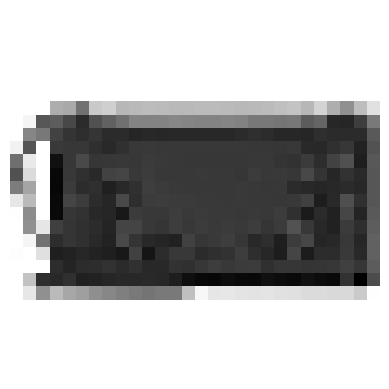

In [ ]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
some_item = X_train[36001]
some_item_image = some_item.reshape(28, 28)
plt.imshow(some_item_image, cmap = matplotlib.cm.binary, interpolation="nearest")
plt.axis("off");


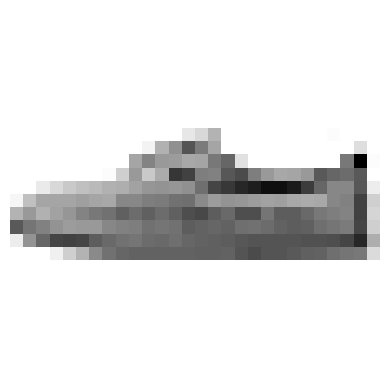

In [ ]:
plot_item(X_train[40000])


In [ ]:
def plot_items(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    images = [instance.reshape(size,size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    n_empty = n_rows * images_per_row - len(instances)
    images.append(np.zeros((size, size * n_empty)))
    for row in range(n_rows):
        rimages = images[row * images_per_row : (row + 1) * images_per_row]
        row_images.append(np.concatenate(rimages, axis=1))
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap = matplotlib.cm.binary, **options)
    plt.axis("off")


Show ten examples from each of the ten classes.


In [ ]:
for cls in range(10):
    plt.figure(figsize=(9, 9))
    example_images = X_train[y_train == cls][:10]
    plot_items(example_images, images_per_row=10)
    plt.title(f"Class {cls}")
    plt.show()


## I.3 Binary classification: shirt vs not-shirt

Class 6 (shirt) is the positive class. An SGD linear classifier on raw pixels is the baseline; later a Random Forest is compared on ROC AUC.


In [ ]:
y_train_shirt = (y_train == 6)
y_test_shirt = (y_test == 6)


In [ ]:
y_train_shirt.shape


(60000,)

In [ ]:
y_test_shirt.shape


(10000,)

Fit SGD (`max_iter=1000`, `tol=1e-3`) and predict on a single example.


In [ ]:
from sklearn.linear_model import SGDClassifier
random_state = 42
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_shirt)


,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [ ]:
sgd_clf.predict([some_item])


array([False])

3-fold cross-validated accuracy. Shirt is only ~10% of the data, so accuracy alone is misleading — a constant “not shirt” predictor already scores ~90%.


In [ ]:
from sklearn.model_selection import cross_val_score
acc = cross_val_score(sgd_clf, X_train, y_train_shirt, cv=3, scoring="accuracy")
print(acc)


[0.88805 0.794   0.91905]


Out-of-fold predictions, confusion matrix, precision, recall, and F1.


In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_shirt, cv=3)


In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_shirt, y_train_pred)


array([[47957,  6043],
       [ 1935,  4065]])

In [ ]:
from sklearn.metrics import precision_score, recall_score
print(precision_score(y_train_shirt, y_train_pred))


0.40215670755836963
0.6775


In [ ]:
print(recall_score(y_train_shirt, y_train_pred))


0.6775


In [ ]:
from sklearn.metrics import f1_score
print(f1_score(y_train_shirt, y_train_pred))


0.504718152470822


## I.4 Threshold, precision–recall, and ROC

Decision scores for every training example let us sweep the classification threshold instead of using the default 0 cutoff.


In [ ]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_shirt, cv=3, n_jobs=-1,
                             method="decision_function")


In [ ]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_shirt, y_scores)


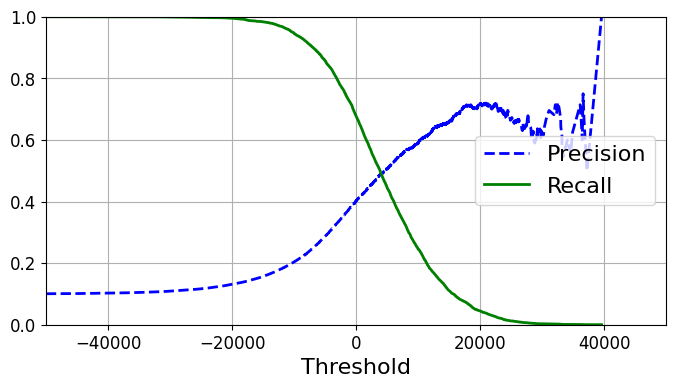

In [ ]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.legend(loc="center right", fontsize=16)
    plt.xlabel("Threshold", fontsize=16)
    plt.grid(True)
    plt.axis([-50000, 50000, 0, 1])
plt.figure(figsize=(8, 4))
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()


Precision vs recall (independent of the threshold axis).


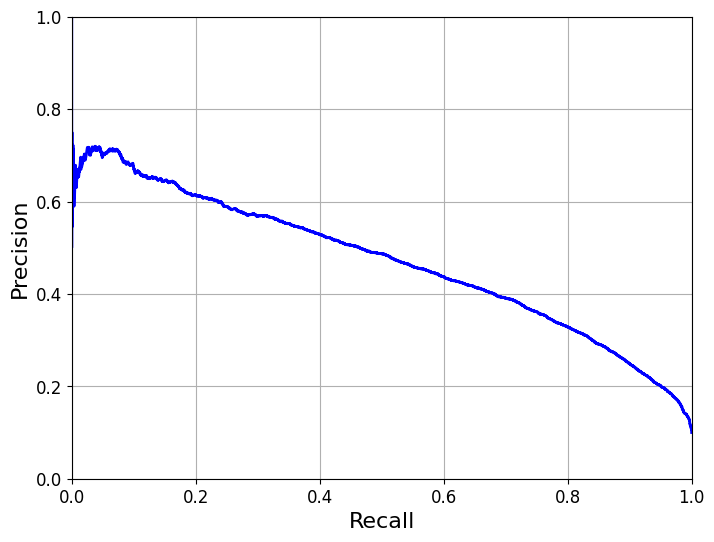

In [ ]:
def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls, precisions, "b-", linewidth=2)
    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    plt.axis([0, 1, 0, 1])
    plt.grid(True)
plt.figure(figsize=(8, 6))
plot_precision_vs_recall(precisions, recalls)
plt.show()


ROC curve and AUC for SGD.


In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_shirt, y_scores)


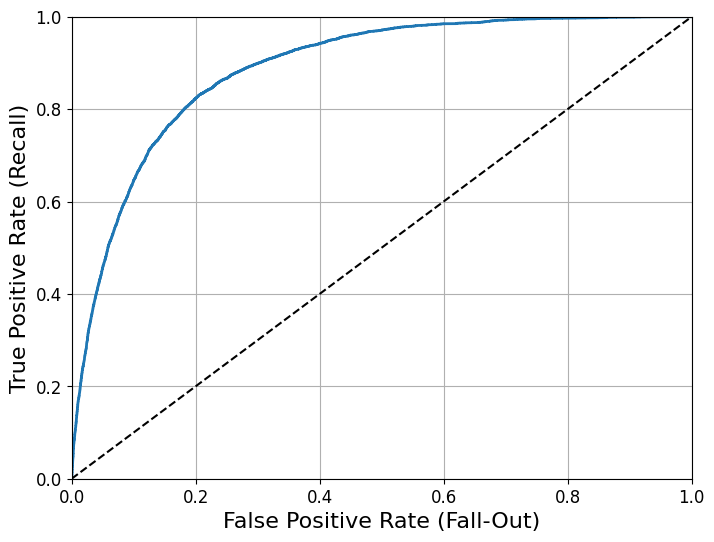

In [ ]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate (Fall-Out)', fontsize=16)
    plt.ylabel('True Positive Rate (Recall)', fontsize=16)
    plt.grid(True)
plt.figure(figsize=(8, 6))
plot_roc_curve(fpr, tpr)
plt.show()


In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_shirt, y_scores)


0.8873327438271605

## I.5 Random Forest binary classifier

Compare ROC curves. Random Forest uses class probability as the score and typically dominates SGD on this task.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_shirt, cv=3, n_jobs=-1,
                                    method="predict_proba")


In [ ]:
y_scores_forest = y_probas_forest[:, 1]
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_shirt,y_scores_forest)


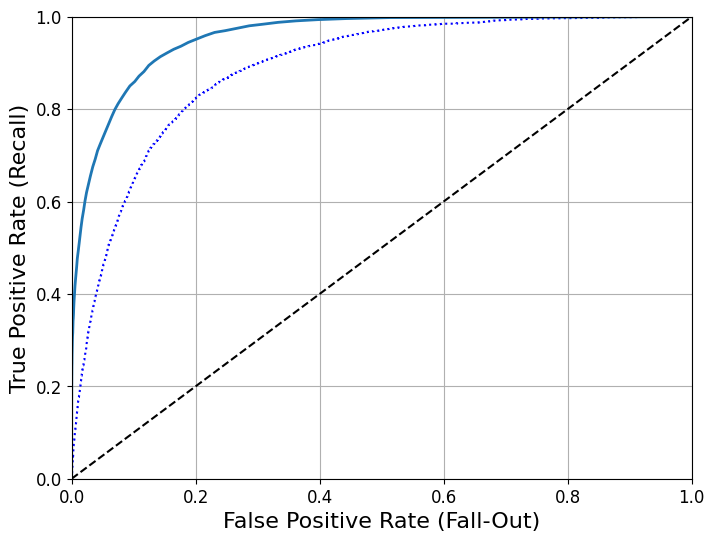

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, "b:", label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.show()


In [ ]:
roc_auc_score(y_train_shirt, y_scores_forest)


0.9562679151234568

## I.6 Multiclass SGD and error analysis

Standardize pixels, fit a 10-way SGD classifier, and inspect the confusion matrix. The off-diagonal heatmap (diagonal zeroed) highlights which classes get mixed up — T-shirts (0) and shirts (6) are the main collision.


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))


In [ ]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(tol=1e-3, random_state=42)
sgd_clf.fit(X_train_scaled[:1000], y_train[:1000])
sgd_clf.predict([some_item])


array([8], dtype=uint8)

In [ ]:
print(y_train[36001])


8


In [ ]:
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3, n_jobs=-1)
conf_mx = confusion_matrix(y_train, y_train_pred)
conf_mx


/Users/mikaeldaluz/Documents/CSE4502/code/venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/mikaeldaluz/Documents/CSE4502/code/venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/mikaeldaluz/Documents/CSE4502/code/venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([[4777,   19,   88,  448,   26,    1,  550,    0,   91,    0],
       [  14, 5685,   38,  199,   15,    1,   45,    0,    3,    0],
       [  42,    5, 4367,   90,  772,    0,  663,    0,   61,    0],
       [ 212,  105,   76, 5205,  191,    0,  199,    0,   12,    0],
       [   8,    5,  617,  330, 4449,    0,  568,    0,   23,    0],
       [   4,    2,    3,   11,    2, 5489,   18,  277,   72,  122],
       [ 806,   18,  635,  372,  550,    0, 3441,    1,  176,    1],
       [   0,    0,    0,    0,    0,  319,    0, 5422,   16,  243],
       [  31,    3,   28,  121,   33,   11,  138,   35, 5595,    5],
       [   0,    0,    0,    6,    1,  100,    7,  251,    4, 5631]])

In [ ]:
def plot_confusion_matrix(matrix):
    """If you prefer color and a colorbar"""
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111)
    cax = ax.matshow(matrix)
    fig.colorbar(cax)


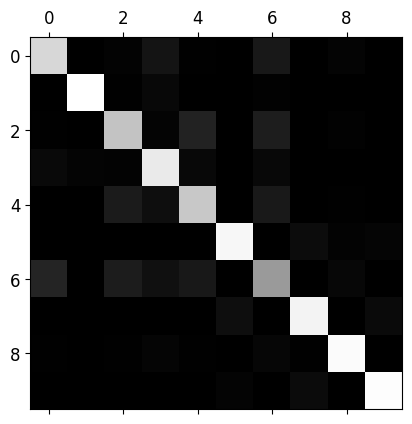

In [ ]:
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()


In [ ]:
row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums


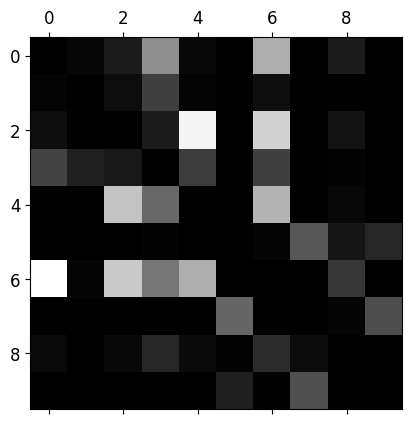

In [ ]:
np.fill_diagonal(norm_conf_mx, 0)
plt.matshow(norm_conf_mx, cmap=plt.cm.gray)
plt.show()


Visualize the T-shirt/shirt mix-ups: correct T-shirts, T-shirts predicted as shirts, shirts predicted as T-shirts, and correct shirts.


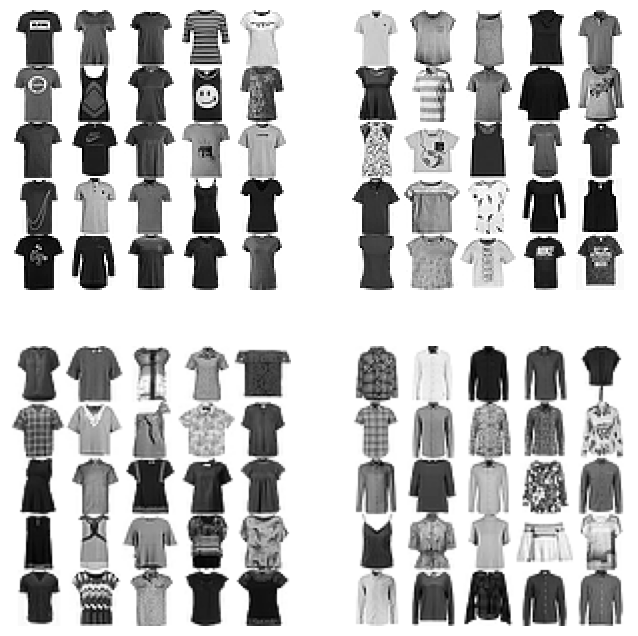

In [ ]:
cl_a, cl_b = 0, 6
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]
plt.figure(figsize=(8,8))
plt.subplot(221); plot_items(X_aa[:25], images_per_row=5)
plt.subplot(222); plot_items(X_ab[:25], images_per_row=5)
plt.subplot(223); plot_items(X_ba[:25], images_per_row=5)
plt.subplot(224); plot_items(X_bb[:25], images_per_row=5)
plt.show()


## I.7 Multiclass Random Forest

A 100-tree forest on scaled pixels, 3-fold CV on train, then test-set accuracy (target: above 85%).


In [ ]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)


In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(forest_clf, X_train_scaled, y_train, cv=3, n_jobs=-1, scoring="accuracy")


array([0.8761, 0.8816, 0.8799])

In [ ]:
forest_clf.fit(X_train_scaled, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
X_test_scaled = scaler.transform(X_test.astype(np.float64))
y_predict_test = forest_clf.predict(X_test_scaled)


In [ ]:
accuarcy =  np.sum(y_predict_test == y_test) / len(y_test)
print(accuarcy)


0.8747


**Part I takeaway:** linear SGD is fast and good for diagnostics; Random Forest clears 85% on 10-way Fashion-MNIST. Shirts vs T-shirts remain the hardest visual pair — a theme the CNN in Part III is better equipped to handle.


# Part II — MLP, PCA, and Hyperparameter Search

Same Fashion-MNIST images, now as a neural net. Train a small MLP on all 784 pixels, then compress with PCA (keep 95% of variance) and train the **same** topology on the reduced features. Finally search a deeper MLP on the PCA space with `RandomizedSearchCV`.


## II.1 Reload data and train a baseline MLP

Pixel values scaled to [0, 1], labels one-hot encoded, first 5,000 training images held out as validation.


In [ ]:
import tensorflow as tf
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()


In [ ]:
np.random.seed(42)
tf.random.set_seed(42)


In [ ]:
from keras import models
from keras import layers
network = models.Sequential()
network.add(layers.Dense(64, activation='relu', input_shape=(28 * 28,)))
network.add(layers.Dense(10, activation='softmax'))


/Users/mikaeldaluz/Documents/CSE4502/code/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
network.compile(optimizer='rmsprop',
                loss='categorical_crossentropy',
                metrics=['accuracy'])


In [ ]:
X_train_full = X_train_full.reshape((60000, 28 * 28))
X_train_full = X_train_full.astype('float32') / 255
X_test = X_test.reshape((10000, 28 * 28))
X_test = X_test.astype('float32') / 255


In [ ]:
from tensorflow.keras.utils import to_categorical
y_train_full = to_categorical(y_train_full)
y_test = to_categorical(y_test)


In [ ]:
X_valid = X_train_full[:5000]
y_valid = y_train_full[:5000]
X_train = X_train_full[5000:]
y_train = y_train_full[5000:]


In [ ]:
network.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=20, batch_size=128)


Epoch 1/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7873 - loss: 0.6159 - val_accuracy: 0.8496 - val_loss: 0.4505
Epoch 2/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8427 - loss: 0.4451 - val_accuracy: 0.8622 - val_loss: 0.4052
Epoch 3/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 975us/step - accuracy: 0.8565 - loss: 0.4012 - val_accuracy: 0.8698 - val_loss: 0.3813
Epoch 4/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8656 - loss: 0.3730 - val_accuracy: 0.8720 - val_loss: 0.3657
Epoch 5/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8730 - loss: 0.3521 - val_accuracy: 0.8740 - val_loss: 0.3561
Epoch 6/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step - accuracy: 0.8782 - loss: 0.3356 - val_accuracy: 0.8748 - val_loss: 0.3519
Epoch 7/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step - accuracy: 0.8825 - loss: 0.3216 - val_accuracy: 0.8780 - val_loss: 0.3458
Epoch 8/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step - accuracy: 0.8867 - loss: 0.3102 - val_accu

In [ ]:
test_loss, test_acc = network.evaluate(X_test, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 382us/step - accuracy: 0.8728 - loss: 0.3866


In [ ]:
print('test_acc:', test_acc)


test_acc: 0.8727999925613403


## II.2 PCA to 95% explained variance

Reload raw (unscaled) flattened images, fit PCA on the full training set, and project train and test. The MLP input size becomes `pca.n_components_` instead of 784.


In [ ]:
import tensorflow as tf
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()


In [ ]:
np.random.seed(42)
tf.random.set_seed(42)


In [ ]:
X_train_full.shape


(60000, 28, 28)

In [ ]:
X_test.shape


(10000, 784)

In [ ]:
X_train_full = X_train_full.reshape((60000,28*28))
X_test = X_test.reshape((10000,28*28))


In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95, svd_solver='full', random_state=42)
X_train_reduced_full = pca.fit_transform(X_train_full)
X_test_reduced = pca.transform(X_test)


In [ ]:
X_test_reduced = pca.transform(X_test)


Same 64-unit hidden layer + 10-way softmax, but the input is the PCA feature vector.


In [ ]:
from keras import models
from keras import layers
network = models.Sequential()
network.add(layers.Dense(64, activation='relu', input_shape=(pca.n_components_,)))
network.add(layers.Dense(10, activation='softmax'))


/Users/mikaeldaluz/Documents/CSE4502/code/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
network.compile(optimizer='rmsprop',
                loss='categorical_crossentropy',
                metrics=['accuracy'])


In [ ]:
X_train_reduced_full = X_train_reduced_full.astype('float32') / 255
X_test_reduced = X_test_reduced.astype('float32') / 255


In [ ]:
from tensorflow.keras.utils import to_categorical
y_train_full = to_categorical(y_train_full)
y_test = to_categorical(y_test)


In [ ]:
X_valid_reduced = X_train_reduced_full[:5000]
y_valid = y_train_full[:5000]
X_train_reduced = X_train_reduced_full[5000:]
y_train = y_train_full[5000:]


In [ ]:
network.fit(X_train_reduced, y_train, validation_data=(X_valid_reduced, y_valid), epochs=20, batch_size=128)


Epoch 1/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - accuracy: 0.7931 - loss: 0.6721 - val_accuracy: 0.8588 - val_loss: 0.4135
Epoch 2/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 532us/step - accuracy: 0.8631 - loss: 0.3877 - val_accuracy: 0.8684 - val_loss: 0.3746
Epoch 3/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 580us/step - accuracy: 0.8742 - loss: 0.3517 - val_accuracy: 0.8762 - val_loss: 0.3544
Epoch 4/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step - accuracy: 0.8817 - loss: 0.3287 - val_accuracy: 0.8808 - val_loss: 0.3405
Epoch 5/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step - accuracy: 0.8884 - loss: 0.3110 - val_accuracy: 0.8840 - val_loss: 0.3305
Epoch 6/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 625us/step - accuracy: 0.8941 - loss: 0.2969 - val_accuracy: 0.8854 - val_loss: 0.3229
Epoch 7/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 685us/step - accuracy: 0.8986 - loss: 0.2850 - val_accuracy: 0.8872 - val_loss: 0.3170
Epoch 8/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step - accuracy: 0.9020 - loss: 0.2749 - 

In [ ]:
test_loss, test_acc = network.evaluate(X_test_reduced, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 362us/step - accuracy: 0.8827 - loss: 0.3386


In [ ]:
print('test_acc:', test_acc)


test_acc: 0.8827000260353088


**What to notice:** PCA keeps most variance with far fewer than 784 dimensions, so training is cheaper. Accuracy is often close to the full-pixel MLP — and can look surprising if the reduced model nearly matches (or even beats) the original because noise/redundant pixels are dropped. Dividing PCA coordinates by 255 is a leftover from pixel scaling; it does not change ranking of features, only their magnitude, which the network can absorb.


## II.3 Randomized search on the PCA features

Wrap a configurable MLP in `KerasClassifier` and search hidden size, depth, dropout, learning rate, batch size, and epochs (12 random draws, 3-fold CV, `n_jobs=-1`). Early stopping on validation accuracy keeps each trial short.


In [ ]:
np.random.seed(42)
tf.random.set_seed(42)


In [ ]:
import numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
np.random.seed(42)
tf.random.set_seed(42)
def to_1d_int(y):
    y = np.asarray(y)
    if y.ndim == 2 and y.shape[1] > 1:
        y = y.argmax(axis=1)
    return y.astype("int64").ravel()
y_train_clean = to_1d_int(y_train_full)
y_test = to_1d_int(y_test)
def build_mlp(hidden_units=256, hidden_layers=2, dropout=0.3, lr=1e-3, input_dim=None):
    if input_dim is None:
        input_dim = X_train_reduced_full.shape[1]
    m = keras.Sequential([layers.Input(shape=(input_dim,))])
    for _ in range(int(hidden_layers)):
        m.add(layers.Dense(int(hidden_units), activation="relu"))
        m.add(layers.Dropout(float(dropout)))
    m.add(layers.Dense(10, activation="softmax"))
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=float(lr)),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    return m
clf = KerasClassifier(model=build_mlp, input_dim=X_train_reduced_full.shape[1], verbose=0)
param_distributions = {
    "model__hidden_units":  [128, 192, 256],
    "model__hidden_layers": [1, 2, 3],
    "model__dropout":       [0.2, 0.3, 0.4],
    "model__lr":            [5e-4, 1e-3, 2e-3],
    "batch_size":           [128, 256],
    "epochs":               [12, 16, 20],
}
early_stop = keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)
search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=12,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    refit=True,
)
search.fit(
    X_train_reduced_full, y_train_clean,
    validation_split=0.1,
    callbacks=[early_stop],
)
print("Best params:", search.best_params_)
print("Best CV acc:", round(search.best_score_, 4))


Best params: {'model__lr': 0.001, 'model__hidden_units': 256, 'model__hidden_layers': 2, 'model__dropout': 0.3, 'epochs': 20, 'batch_size': 256}
Best CV acc: 0.8976


Inspect the winning architecture and evaluate it on the PCA-transformed test set.


In [ ]:
model = search.best_estimator_.model_
model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 256)            │        48,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 349,472 (1.33 MB)

 Trainable params: 116,490 (455.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 232,982 (910.09 KB)

In [ ]:
model.evaluate(X_test_reduced, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 474us/step - accuracy: 0.8964 - loss: 0.3118


[0.311777263879776, 0.896399974822998]

**Part II takeaway:** a tiny MLP already beats the sklearn models from Part I. PCA makes search affordable. A tuned deeper net with dropout and Adam typically improves further on the reduced features.


# Part III — Convolutional Y-Network on Fashion-MNIST

Flattened pixels throw away spatial structure. This part trains a **dual-branch CNN**: the same 28×28×1 image is fed to two conv stacks, concatenated, then classified. Techniques used: `same` padding, batch normalization, dropout, light on-the-fly augmentation, Nadam/Adam, early stopping, and ReduceLROnPlateau. Goal: **>94% test accuracy**, using the test set only at the end.


## III.1 Reload images in 2D form


In [ ]:
import tensorflow as tf
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


In [ ]:
X_train.shape


(60000, 28, 28)

In [ ]:
y_train.shape


(60000,)

In [ ]:
y_test.shape


(10000,)

Quick visual check of a few examples (same 10 class labels as Part I).


In [ ]:
def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = matplotlib.cm.binary, interpolation="nearest")
    plt.axis("off")


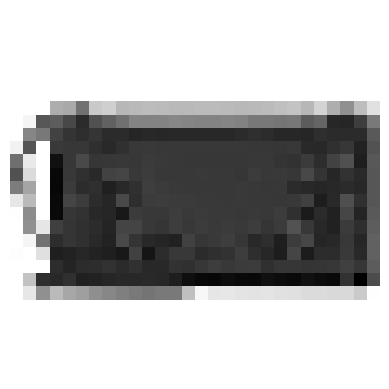

In [ ]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
some_digit = X_train[36001]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap = matplotlib.cm.binary, interpolation="nearest")
plt.axis("off");


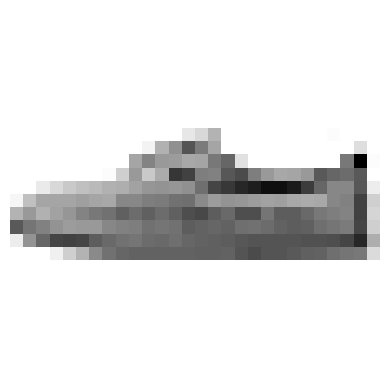

In [ ]:
plot_digit(X_train[40000])


In [ ]:
def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    images = [instance.reshape(size,size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    n_empty = n_rows * images_per_row - len(instances)
    images.append(np.zeros((size, size * n_empty)))
    for row in range(n_rows):
        rimages = images[row * images_per_row : (row + 1) * images_per_row]
        row_images.append(np.concatenate(rimages, axis=1))
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap = matplotlib.cm.binary, **options)
    plt.axis("off")


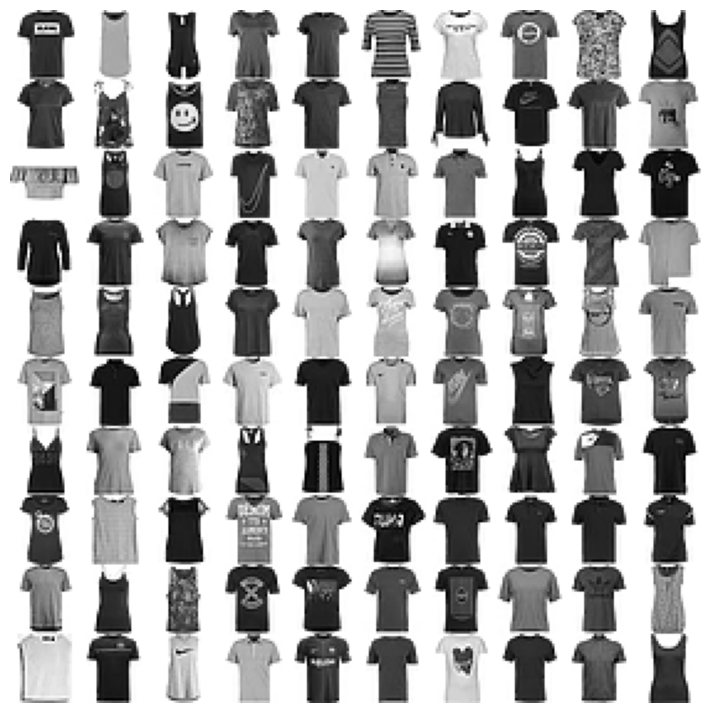

In [ ]:
plt.figure(figsize=(9,9))
X_0 = X_train[(y_train == 0)]
example_images = X_0[:100]
plot_digits(example_images, images_per_row=10)


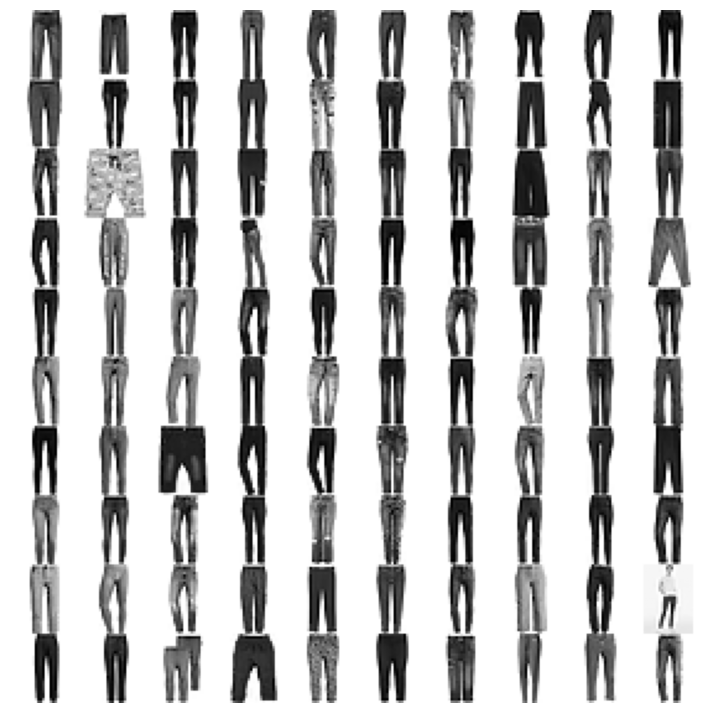

In [ ]:
plt.figure(figsize=(9,9))
X_1 = X_train[(y_train == 1)]
example_images = X_1[:100]
plot_digits(example_images, images_per_row=10)


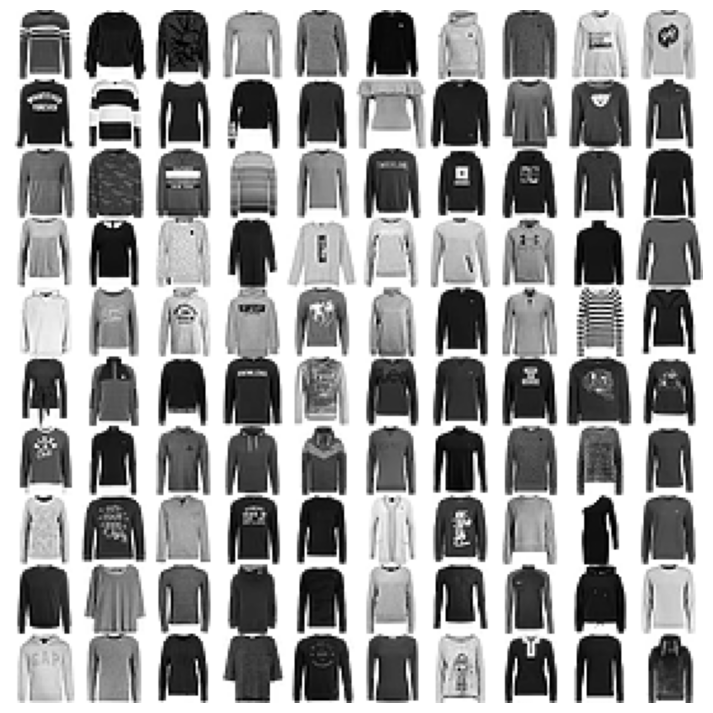

In [ ]:
plt.figure(figsize=(9,9))
X_2 = X_train[(y_train == 2)]
example_images = X_2[:100]
plot_digits(example_images, images_per_row=10)


## III.2 Dual-branch CNN

Each branch: conv → batch norm → conv → batch norm → max-pool → dropout → small random translate/rotate → two more conv layers. Branches are concatenated, then dense layers with batch norm and dropout, and a 10-way softmax.


In [ ]:
from keras import layers
from keras import models
def build_model():
    input_shape=(28, 28, 1)
    left_inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), padding="same", activation='relu')(left_inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), padding="same", activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)
    x = layers.RandomTranslation(0.05, 0.05)(x)
    x = layers.RandomRotation(0.05)(x)
    x = layers.Conv2D(32, (3, 3), padding="same", activation='relu')(x)
    x = layers.Conv2D(32, (3, 3), padding="same", activation='relu')(x)
    right_inputs = layers.Input(shape=input_shape)
    y = layers.Conv2D(32, (3, 3), padding="same", activation='relu')(right_inputs)
    y = layers.BatchNormalization()(y)
    y = layers.Conv2D(32, (3, 3), padding="same", activation='relu')(y)
    y = layers.BatchNormalization()(y)
    y = layers.MaxPooling2D((2, 2))(y)
    y = layers.Dropout(0.25)(y)
    y = layers.RandomTranslation(0.05, 0.05)(y)
    y = layers.RandomRotation(0.05)(y)
    y = layers.Conv2D(32, (3, 3), padding="same", activation='relu')(y)
    y = layers.Conv2D(32, (3, 3), padding="same", activation='relu')(y)
    x = layers.concatenate([x, y])
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    model = models.Model([left_inputs, right_inputs], outputs=outputs)
    return model
model = build_model()
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 28, 28,    │        320 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 28, 28,    │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 28, 28,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 28, 28,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 14, 14,    │          0 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 14, 14,    │          0 │ max_pooling2d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation… │ (None, 14, 14,    │          0 │ dropout_3[0][0]   │
│ (RandomTranslation) │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation… │ (None, 14, 14,    │          0 │ dropout_4[0][0]   │
│ (RandomTranslation) │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_2   │ (None, 14, 14,    │          0 │ random_translati

 Total params: 6,616,650 (25.24 MB)

 Trainable params: 6,614,858 (25.23 MB)

 Non-trainable params: 1,792 (7.00 KB)

Reshape to `(N, 28, 28, 1)`, scale to [0, 1], one-hot labels. First 10,000 training images are a validation split for the first training run.


In [ ]:
from tensorflow.keras.utils import to_categorical
X_train = X_train.reshape((60000, 28, 28, 1))
X_train = X_train.astype('float32') / 255
y_train = to_categorical(y_train)
X_test = X_test.reshape((10000, 28, 28, 1))
X_test = X_test.astype('float32') / 255
y_test = to_categorical(y_test)
X_val = X_train[:10000]
y_val = y_train[:10000]
X_train_partial = X_train[10000:]
y_train_partial = y_train[10000:]


In [ ]:
X_train_partial.shape, y_train_partial.shape, X_test.shape, y_test.shape


((50000, 28, 28, 1), (50000, 10), (10000, 28, 28, 1), (10000, 10))

## III.3 First training run (Nadam)

Train 40 epochs on the partial split and plot loss/accuracy. Use this to see whether the model is underfitting or overfitting before touching the test set.


In [ ]:
model.compile(optimizer='nadam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit([X_train_partial, X_train_partial], y_train_partial, epochs=40, batch_size=32, validation_data=([X_val, X_val], y_val))


Epoch 1/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 107s 66ms/step - accuracy: 0.8157 - loss: 0.5367 - val_accuracy: 0.8818 - val_loss: 0.3282
Epoch 2/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 104s 67ms/step - accuracy: 0.8720 - loss: 0.3566 - val_accuracy: 0.9007 - val_loss: 0.2659
Epoch 3/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 105s 67ms/step - accuracy: 0.8882 - loss: 0.3122 - val_accuracy: 0.9035 - val_loss: 0.2604
Epoch 4/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 102s 65ms/step - accuracy: 0.8968 - loss: 0.2878 - val_accuracy: 0.9190 - val_loss: 0.2291
Epoch 5/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 107s 68ms/step - accuracy: 0.9051 - loss: 0.2658 - val_accuracy: 0.9233 - val_loss: 0.2078
Epoch 6/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 106s 68ms/step - accuracy: 0.9099 - loss: 0.2496 - val_accuracy: 0.9150 - val_loss: 0.2266
Epoch 7/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 113s 72ms/step - accuracy: 0.9144 - loss: 0.2391 - val_accuracy: 0.9260 - val_loss: 0.2011
Epoch 8/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 109s 70ms/step - accuracy: 

In [ ]:
history.history.keys()


Epoch 1/40
211/211 - 161s - 765ms/step - accuracy: 0.8193 - loss: 0.5198 - val_accuracy: 0.8902 - val_loss: 0.3035 - learning_rate: 0.0010
Epoch 2/40
211/211 - 153s - 724ms/step - accuracy: 0.8814 - loss: 0.3298 - val_accuracy: 0.8875 - val_loss: 0.3165 - learning_rate: 0.0010
Epoch 3/40
211/211 - 155s - 735ms/step - accuracy: 0.8970 - loss: 0.2839 - val_accuracy: 0.9138 - val_loss: 0.2433 - learning_rate: 0.0010
Epoch 4/40
211/211 - 203s - 960ms/step - accuracy: 0.9056 - loss: 0.2573 - val_accuracy: 0.9180 - val_loss: 0.2304 - learning_rate: 0.0010
Epoch 5/40
211/211 - 135s - 639ms/step - accuracy: 0.9093 - loss: 0.2444 - val_accuracy: 0.9217 - val_loss: 0.2222 - learning_rate: 0.0010
Epoch 6/40
211/211 - 138s - 655ms/step - accuracy: 0.9171 - loss: 0.2285 - val_accuracy: 0.9247 - val_loss: 0.2184 - learning_rate: 0.0010
Epoch 7/40
211/211 - 142s - 671ms/step - accuracy: 0.9221 - loss: 0.2147 - val_accuracy: 0.9262 - val_loss: 0.2109 - learning_rate: 0.0010
Epoch 8/40
211/211 - 144s -

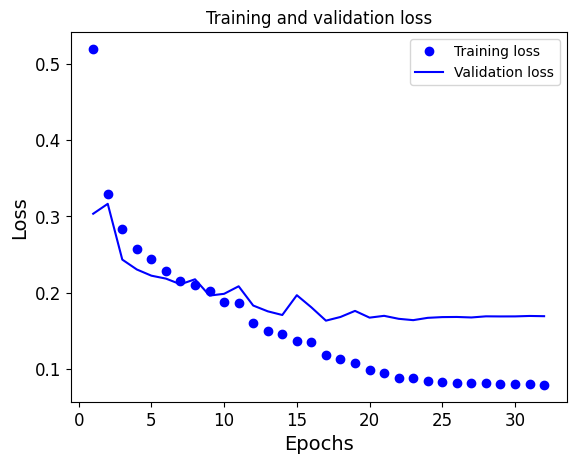

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


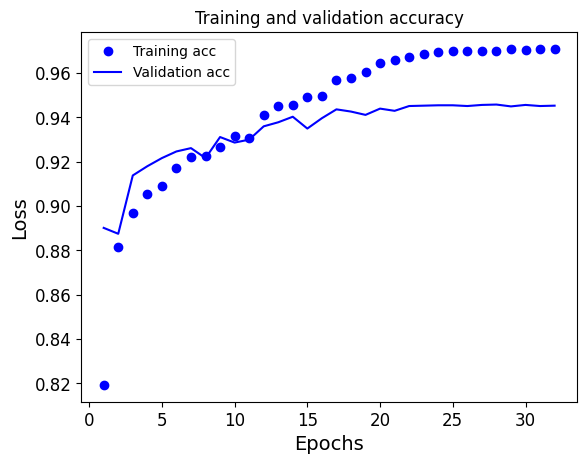

In [ ]:
plt.clf()
acc_values = history.history['accuracy']
val_acc_values = history.history['val_accuracy']
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


## III.4 Retrain with callbacks, then test once

Rebuild, train on (almost) all training data with `validation_split=0.1`, stop when validation accuracy stalls, and decay the learning rate on plateau. Evaluate the test set a single time.


In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
    jit_compile=True,
)
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5),
]
history = model.fit(
    [X_train, X_train], y_train,
    epochs=40,
    batch_size=256,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
               ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)],
    verbose=2
)


Epoch 1/40
211/211 - 96s - 454ms/step - accuracy: 0.8530 - loss: 0.4334 - val_accuracy: 0.8900 - val_loss: 0.3168 - learning_rate: 0.0010
Epoch 2/40
211/211 - 92s - 437ms/step - accuracy: 0.9034 - loss: 0.2678 - val_accuracy: 0.9167 - val_loss: 0.2307 - learning_rate: 0.0010
Epoch 3/40
211/211 - 82s - 389ms/step - accuracy: 0.9181 - loss: 0.2295 - val_accuracy: 0.9115 - val_loss: 0.2526 - learning_rate: 0.0010
Epoch 4/40
211/211 - 87s - 412ms/step - accuracy: 0.9269 - loss: 0.2037 - val_accuracy: 0.9197 - val_loss: 0.2210 - learning_rate: 0.0010
Epoch 5/40
211/211 - 92s - 437ms/step - accuracy: 0.9338 - loss: 0.1821 - val_accuracy: 0.9198 - val_loss: 0.2196 - learning_rate: 0.0010
Epoch 6/40
211/211 - 87s - 413ms/step - accuracy: 0.9394 - loss: 0.1667 - val_accuracy: 0.9275 - val_loss: 0.1992 - learning_rate: 0.0010
Epoch 7/40
211/211 - 87s - 410ms/step - accuracy: 0.9449 - loss: 0.1531 - val_accuracy: 0.9277 - val_loss: 0.2086 - learning_rate: 0.0010
Epoch 8/40
211/211 - 86s - 408ms/s

In [ ]:
acc = model.evaluate([X_test, X_test], y_test, verbose=0)


**Part III takeaway:** convolutions plus regularization beat both sklearn and the MLP. The Y-network and augmentation help the model generalize on the shirt/T-shirt confusion that showed up in Part I.


# Summary

Same images, three skill sets: sklearn diagnostics, dimensionality reduction + MLP tuning, and modern convnets.

| Stage | Model | Typical outcome |
|-------|--------|-----------------|
| Part I | SGD + Random Forest | RF >85% test |
| Part II | MLP ± PCA, then random search | Tuned MLP beats the small MLP |
| Part III | Dual-branch CNN | >94% test |

The hardest visual pair in Part I (shirts vs T-shirts) is exactly where convolutions in Part III help most.
